In [201]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

Чтение файлов

In [202]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [203]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [204]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [205]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


Так как в столбце *Cabin* его проще удалить

In [206]:
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)

In [207]:
train['Age'] = train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'] = test['Age'].fillna(test['Age'].median(), inplace=True)
test['Fare'] = test['Fare'].fillna(test['Fare'].median(), inplace=True)

train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
test['Embarked'] = test['Embarked'].fillna(test['Embarked'].mode()[0], inplace=True)

C:\Users\dimas\AppData\Local\Temp\ipykernel_8880\41052725.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train['Age'] = train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\dimas\AppData\Local\Temp\ipykernel_8880\41052725.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through c

Колонка *Name* не несёт полезного значения

In [208]:
train.drop('Name', axis=1, inplace=True)
test.drop('Name', axis=1, inplace=True)

In [209]:
set(train['Ticket'])

{'110152',
 '110413',
 '110465',
 '110564',
 '110813',
 '111240',
 '111320',
 '111361',
 '111369',
 '111426',
 '111427',
 '111428',
 '112050',
 '112052',
 '112053',
 '112058',
 '112059',
 '112277',
 '112379',
 '113028',
 '113043',
 '113050',
 '113051',
 '113055',
 '113056',
 '113059',
 '113501',
 '113503',
 '113505',
 '113509',
 '113510',
 '113514',
 '113572',
 '113760',
 '113767',
 '113773',
 '113776',
 '113781',
 '113783',
 '113784',
 '113786',
 '113787',
 '113788',
 '113789',
 '113792',
 '113794',
 '113796',
 '113798',
 '113800',
 '113803',
 '113804',
 '113806',
 '113807',
 '11668',
 '11751',
 '11752',
 '11753',
 '11755',
 '11765',
 '11767',
 '11769',
 '11771',
 '11774',
 '11813',
 '11967',
 '12233',
 '12460',
 '12749',
 '13049',
 '13213',
 '13214',
 '13502',
 '13507',
 '13509',
 '13567',
 '13568',
 '14311',
 '14312',
 '14313',
 '14973',
 '1601',
 '16966',
 '16988',
 '17421',
 '17453',
 '17463',
 '17464',
 '17465',
 '17466',
 '17474',
 '17764',
 '19877',
 '19928',
 '19943',
 '19947'

Так как *Ticket* имеет слишком много уникальных значений, есть смысл оставить только буквенный префикс, а потом посмотреть влияет ли он на *Survived*

In [210]:
train['ticket_prefix'] = train['Ticket'].str.extract(r'([A-Za-z]+)').fillna('NUMERIC')
train.drop('Ticket', axis=1, inplace=True)
train['ticket_prefix'] = train['ticket_prefix'].apply(lambda x: 'RARE' if x in ['F', 'LINE', 'PP', 'P', 'WE', 'SO', 'Fa', 'SW', 'SCO'] else x)
print(train['ticket_prefix'].value_counts())

ticket_prefix
NUMERIC    661
PC          60
C           33
A           29
RARE        21
STON        18
SOTON       17
S           14
CA          14
SC          13
W           11
Name: count, dtype: int64


In [211]:
test['ticket_prefix'] = test['Ticket'].str.extract(r'([A-Za-z]+)').fillna('NUMERIC')
test.drop('Ticket', axis=1, inplace=True)
test['ticket_prefix'] = test['ticket_prefix'].apply(lambda x: 'RARE' if x in ['F', 'LINE', 'PP', 'P', 'WE', 'SO', 'Fa', 'SW', 'SCO'] else x)
print(test['ticket_prefix'].value_counts())

ticket_prefix
NUMERIC    296
PC          32
C           22
SC          12
A           11
SOTON       10
CA           8
RARE         7
S            7
W            6
STON         4
AQ           2
LP           1
Name: count, dtype: int64


In [212]:
train['ticket_prefix'] = train['ticket_prefix'].astype('category')
train['Embarked'] = train['Embarked'].astype('category')
train['Sex'] = train['Sex'].astype('category')

In [213]:
test['ticket_prefix'] = test['ticket_prefix'].astype('category')
test['Sex'] = test['Sex'].astype('category')
test['Embarked'] = test['Embarked'].astype('category')

In [214]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   PassengerId    891 non-null    int64   
 1   Survived       891 non-null    int64   
 2   Pclass         891 non-null    int64   
 3   Sex            891 non-null    category
 4   Age            891 non-null    float64 
 5   SibSp          891 non-null    int64   
 6   Parch          891 non-null    int64   
 7   Fare           891 non-null    float64 
 8   Embarked       891 non-null    category
 9   ticket_prefix  891 non-null    category
dtypes: category(3), float64(2), int64(5)
memory usage: 51.6 KB


In [215]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   PassengerId    418 non-null    int64   
 1   Pclass         418 non-null    int64   
 2   Sex            418 non-null    category
 3   Age            418 non-null    float64 
 4   SibSp          418 non-null    int64   
 5   Parch          418 non-null    int64   
 6   Fare           418 non-null    float64 
 7   Embarked       418 non-null    category
 8   ticket_prefix  418 non-null    category
dtypes: category(3), float64(2), int64(4)
memory usage: 21.1 KB


Сгруппирую характеристики по типу данных

In [216]:
num_cols = [name for name in train.columns if train[name].dtype != 'category' and name != 'Survived']
cat_cols = [name for name in train.columns if train[name].dtype == 'category' and name != 'Survived']
target = 'Survived'

Теперь проверю корреляцию *числовых характеристик* к *Survived*

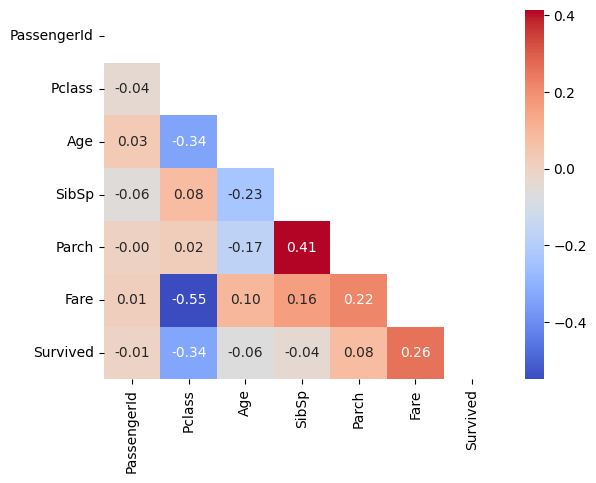

In [217]:
matrix = train[num_cols + [target]].corr()
mask = np.triu(np.ones_like(matrix, dtype=bool))
sns.heatmap(matrix, mask=mask,  annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

Из числовых характеристик оставлю только *Pclass, Parch, Fare*

In [218]:
print(set(train['ticket_prefix']))

{'SOTON', 'A', 'NUMERIC', 'PC', 'SC', 'CA', 'RARE', 'W', 'S', 'C', 'STON'}


Теперь проверю категориальных характеристики

In [219]:
model = ols("Survived ~ C(Sex) * C(Embarked) * C(ticket_prefix)", data=train).fit()

anova_results = anova_lm(model)
print(anova_results)


                                        df      sum_sq    mean_sq           F  \
C(Sex)                                 1.0   62.213165  62.213165  398.769705   
C(Embarked)                            2.0    3.287940   1.643970   10.537407   
C(ticket_prefix)                      10.0    5.698828   0.569883    3.652796   
C(Sex):C(Embarked)                     2.0    0.434857   0.217428    1.393658   
C(Sex):C(ticket_prefix)               10.0    3.966767   0.396677    2.542591   
C(Embarked):C(ticket_prefix)          20.0    3.362229   0.168111    1.077549   
C(Sex):C(Embarked):C(ticket_prefix)   20.0    2.882432   0.144122    0.923781   
Residual                             857.0  133.702941   0.156013         NaN   

                                           PR(>F)  
C(Sex)                               3.825458e-73  
C(Embarked)                          3.013184e-05  
C(ticket_prefix)                     8.629656e-05  
C(Sex):C(Embarked)                   2.487277e-01  
C(Sex):C(t

Точно возьму *Sex* и *Embarked*, *ticket_prefix* под сомнением

In [220]:
stats = train.groupby('ticket_prefix').agg(
    выживаемость = ('Survived', 'mean'),
    всего=('Survived', 'count'),
    выжило=('Survived', 'sum')
)
stats

,выживаемость,всего,выжило
ticket_prefix,,,
A,0.068966,29,2
C,0.454545,33,15
CA,0.071429,14,1
NUMERIC,0.384266,661,254
PC,0.650000,60,39
RARE,0.523810,21,11
S,0.142857,14,2
SC,0.538462,13,7
SOTON,0.117647,17,2


Объединим в numeric группы с выживаемостью около 50%

In [221]:
train['ticket_prefix'] = train['ticket_prefix'].apply(lambda x: 'NUMERIC' if abs(stats.loc[x].выживаемость-0.5) < 0.1 else x)

In [222]:
train['ticket_prefix'].unique()

<StringArray>
['A', 'PC', 'NUMERIC', 'S', 'CA', 'W', 'SOTON']
Length: 7, dtype: str

Проверим на сбалансированность класс *Survived*

In [232]:
survived_neg = (train['Survived'] == 0).sum()
survived_pos = (train['Survived'] == 1).sum()

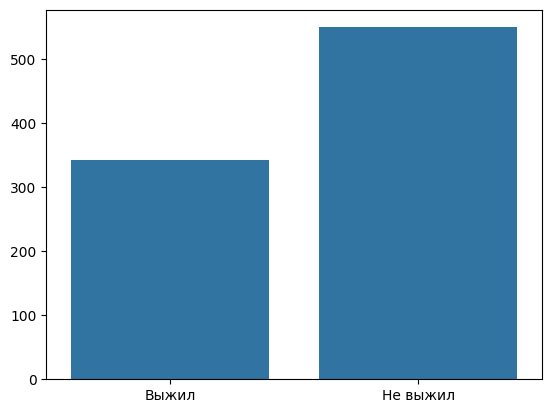

In [233]:
sns.barplot(x=['Выжил', 'Не выжил'], y=[survived_pos, survived_neg])
plt.show()

Классы *не сбалансированны*, это надо будет учитывать

Итого

In [223]:
selected_features = ['Pclass', 'Parch', 'Fare', 'Sex', 'Embarked', 'ticket_prefix']

In [224]:
train[['PassengerId'] + selected_features + [target]].to_csv('prepared_train.csv', index=False)

In [225]:
test[['PassengerId'] + selected_features].to_csv('prepared_test.csv', index=False)